# Kilian (2007) Dataset: Time-variant parameter Bayesian VAR Replication

This notebook duplicates the original data workflow but estimates a Bayesian VAR with NIW prior and Gibbs sampling.

## Setup

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import invwishart
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.api import VAR
from statsmodels.stats.diagnostic import acorr_ljungbox

plt.style.use('seaborn-v0_8-whitegrid')
np.set_printoptions(suppress=True, precision=4)

BASE_DIR = Path('/Users/tyau/Desktop/cornell course/spring/ECON 7300 bayes time series/project/lutz_kilian')

## Load the Kilian VAR data

In [2]:
data = np.loadtxt(BASE_DIR / 'data.txt')
cols = ['d_prod', 'rea', 'rpo']
df = pd.DataFrame(data, columns=cols)
df.head(), df.shape

(      d_prod        rea        rpo
 0  11.877264  36.064235 -47.999534
 1   1.419150  41.527016 -48.286474
 2   1.177711  43.991250 -47.082500
 3  27.455136  48.105889 -43.857651
 4 -13.110436  52.033462 -41.571063,
 (419, 3))

## TAP-BVAR(24) with NIW prior and Gibbs sampling
$Y(t) = \phi_0 + \phi_1 Y(t-1) + \phi_2 Y(t-2) + ... + \phi_24 Y(t-24) + \epsilon(t) : \epsilon(t) \sim N(0, \Sigma), \Sigma \sim IW(\nu_0, S_0)$

$\phi_t = \phi_{t-1} + \eta_t : \eta_t \sim N(0, Q)$

In [3]:
def make_var_regressors(y, p):
    T, n = y.shape
    Y = y[p:, :]
    X_lags = []
    for t in range(p, T):
        row = []
        for L in range(1, p + 1):
            row.extend(y[t - L, :])
        X_lags.append(row)
    X_lags = np.asarray(X_lags)
    X = np.column_stack([np.ones(X_lags.shape[0]), X_lags])
    return Y, X


def sample_beta_path(Y, X, Sigma, Q, beta0, P0, rng):
    """
    Carter-Kohn style simulation smoother for:
        y_t = H_t beta_t + eps_t, eps_t ~ N(0, Sigma)
        beta_t = beta_{t-1} + eta_t, eta_t ~ N(0, Q)
    where H_t = kron(I_n, x_t').
    """
    T_eff, n = Y.shape
    k = X.shape[1]
    m = k * n

    beta_pred = np.zeros((T_eff, m))
    P_pred = np.zeros((T_eff, m, m))
    beta_filt = np.zeros((T_eff, m))
    P_filt = np.zeros((T_eff, m, m))

    b_prev = beta0.copy()
    P_prev = P0.copy()

    for t in range(T_eff):
        b_pr = b_prev
        P_pr = P_prev + Q

        H_t = np.kron(np.eye(n), X[t:t+1, :])
        y_t = Y[t]

        S_t = H_t @ P_pr @ H_t.T + Sigma
        K_t = P_pr @ H_t.T @ np.linalg.inv(S_t)
        innov = y_t - H_t @ b_pr

        b_upd = b_pr + K_t @ innov
        P_upd = P_pr - K_t @ H_t @ P_pr
        P_upd = 0.5 * (P_upd + P_upd.T)

        beta_pred[t] = b_pr
        P_pred[t] = P_pr
        beta_filt[t] = b_upd
        P_filt[t] = P_upd

        b_prev = b_upd
        P_prev = P_upd

    beta_path = np.zeros((T_eff, m))
    beta_path[-1] = rng.multivariate_normal(beta_filt[-1], P_filt[-1])

    for t in range(T_eff - 2, -1, -1):
        J_t = P_filt[t] @ np.linalg.inv(P_pred[t + 1])
        mean_t = beta_filt[t] + J_t @ (beta_path[t + 1] - beta_pred[t + 1])
        cov_t = P_filt[t] - J_t @ P_pred[t + 1] @ J_t.T
        cov_t = 0.5 * (cov_t + cov_t.T)
        beta_path[t] = rng.multivariate_normal(mean_t, cov_t)

    return beta_path


def gibbs_tvp_bvar_niw(y, p=24, n_draws=12000, burn=2000, seed=42):
    rng = np.random.default_rng(seed)
    Y, X = make_var_regressors(y, p)
    T_eff, n = Y.shape
    k = X.shape[1]
    m = k * n

    # Priors for initial state beta_0
    B0 = np.zeros((k, n))
    beta0 = B0.reshape(-1, order='F')
    P0 = np.eye(m) * 10.0

    # NIW prior for Sigma
    nu0 = n + 2
    S0 = np.eye(n)

    # IW prior for Q (state innovation covariance)
    nuQ0 = m + 2
    SQ0 = np.eye(m) * 1e-4

    # OLS-based initialization
    B_ols = np.linalg.solve(X.T @ X, X.T @ Y)
    E_ols = Y - X @ B_ols
    Sigma = (E_ols.T @ E_ols) / T_eff

    # Small random walk variance at initialization
    Q = np.eye(m) * 1e-4

    keep = n_draws - burn
    B_draws = np.zeros((keep, T_eff, k, n))
    Sigma_draws = np.zeros((keep, n, n))
    Q_draws = np.zeros((keep, m, m))
    B_trace = np.zeros((n_draws, 4))
    S_trace = np.zeros((n_draws, n))

    for it in range(n_draws):
        # 1) Sample entire coefficient path beta_{1:T}
        beta_path = sample_beta_path(Y, X, Sigma, Q, beta0, P0, rng)

        # 2) Sample Q from inverse-Wishart using state innovations
        db = beta_path[1:] - beta_path[:-1]
        scale_Q = SQ0 + db.T @ db
        nuQ = nuQ0 + (T_eff - 1)
        Q = invwishart.rvs(df=nuQ, scale=scale_Q, random_state=rng)

        # 3) Sample Sigma from inverse-Wishart using observation residuals
        resid = np.zeros((T_eff, n))
        for t in range(T_eff):
            B_t = beta_path[t].reshape((k, n), order='F')
            resid[t] = Y[t] - X[t] @ B_t

        scale_S = S0 + resid.T @ resid
        nuS = nu0 + T_eff
        Sigma = invwishart.rvs(df=nuS, scale=scale_S, random_state=rng)

        B_last = beta_path[-1].reshape((k, n), order='F')
        B_trace[it, :] = [B_last[0, 0], B_last[1, 0], B_last[1, 1], B_last[2, 2]]
        S_trace[it, :] = np.diag(Sigma)

        if it >= burn:
            j = it - burn
            B_draws[j] = beta_path.reshape(T_eff, k, n, order='C')
            Sigma_draws[j] = Sigma
            Q_draws[j] = Q

    out = {
        'Y': Y,
        'X': X,
        'B_draws': B_draws,
        'Sigma_draws': Sigma_draws,
        'Q_draws': Q_draws,
        'B_mean_t': B_draws.mean(axis=0),
        'B_mean_last': B_draws.mean(axis=0)[-1],
        'Sigma_mean': Sigma_draws.mean(axis=0),
        'Q_mean': Q_draws.mean(axis=0),
        'B_trace': B_trace,
        'S_trace': S_trace
    }
    return out


p = 6
n_draws = 3000
burn = 500

bvar = gibbs_tvp_bvar_niw(df.values, p=p, n_draws=n_draws, burn=burn, seed=42)
bvar['B_mean_t'].shape, bvar['Sigma_mean']

((413, 19, 3),
 array([[395.1189,   6.1084,  -5.2541],
        [  6.1084,  15.962 ,   1.983 ],
        [ -5.2541,   1.983 ,  31.886 ]]))

## MCMC trace plots (visual convergence check)

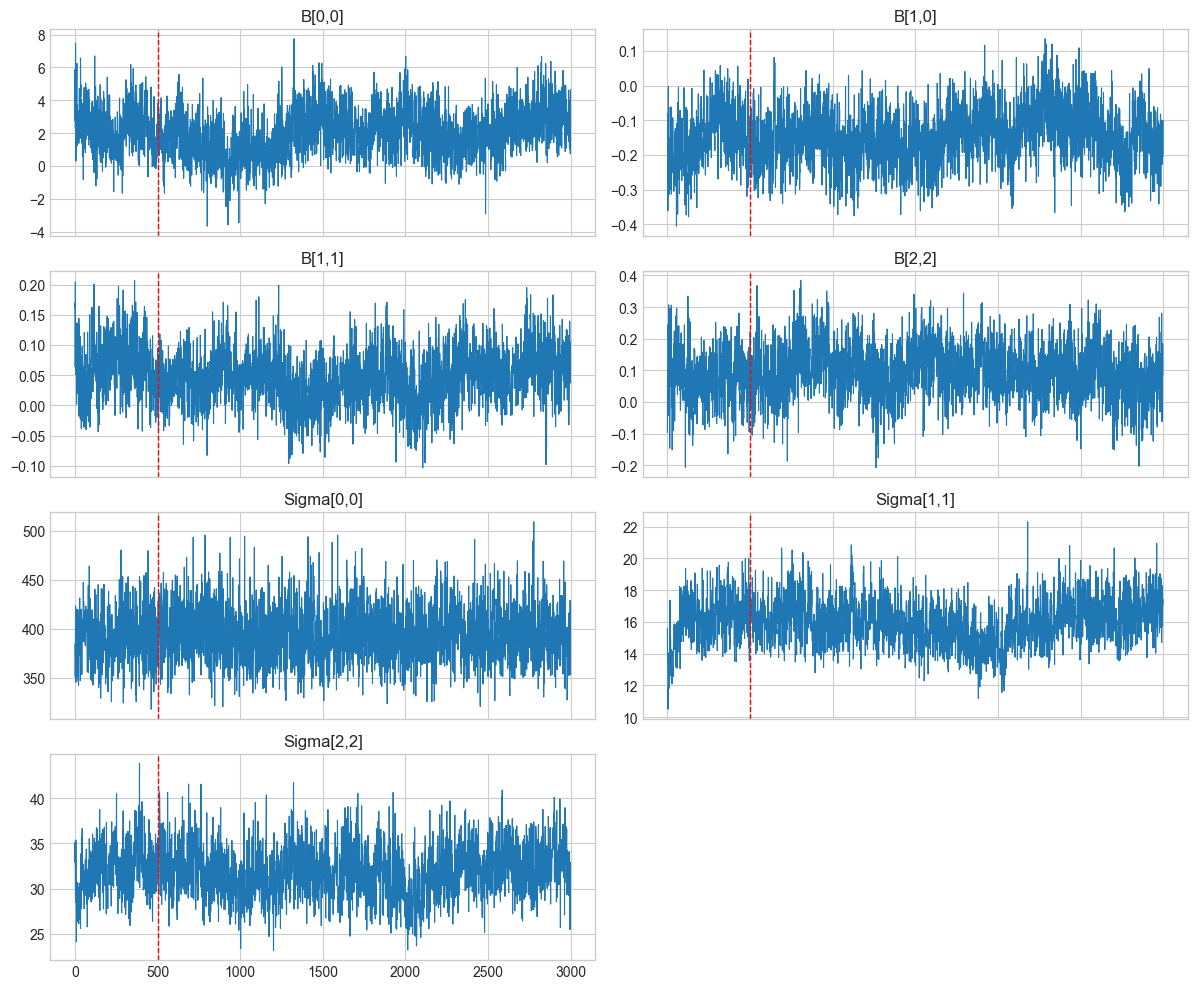

In [4]:
fig, axes = plt.subplots(4, 2, figsize=(12, 10), sharex=True)
axes = axes.ravel()

trace_names = ['B[0,0]', 'B[1,0]', 'B[1,1]', 'B[2,2]']
for i in range(4):
    axes[i].plot(bvar['B_trace'][:, i], lw=0.8)
    axes[i].axvline(burn, color='r', ls='--', lw=1)
    axes[i].set_title(trace_names[i])

sig_names = ['Sigma[0,0]', 'Sigma[1,1]', 'Sigma[2,2]']
for i in range(3):
    axes[4+i].plot(bvar['S_trace'][:, i], lw=0.8)
    axes[4+i].axvline(burn, color='r', ls='--', lw=1)
    axes[4+i].set_title(sig_names[i])

axes[-1].axis('off')
plt.tight_layout()
plt.show()

## Running posterior mean over iterations

This plots the cumulative posterior mean (after burn-in) to visually inspect stabilization over MCMC draws.

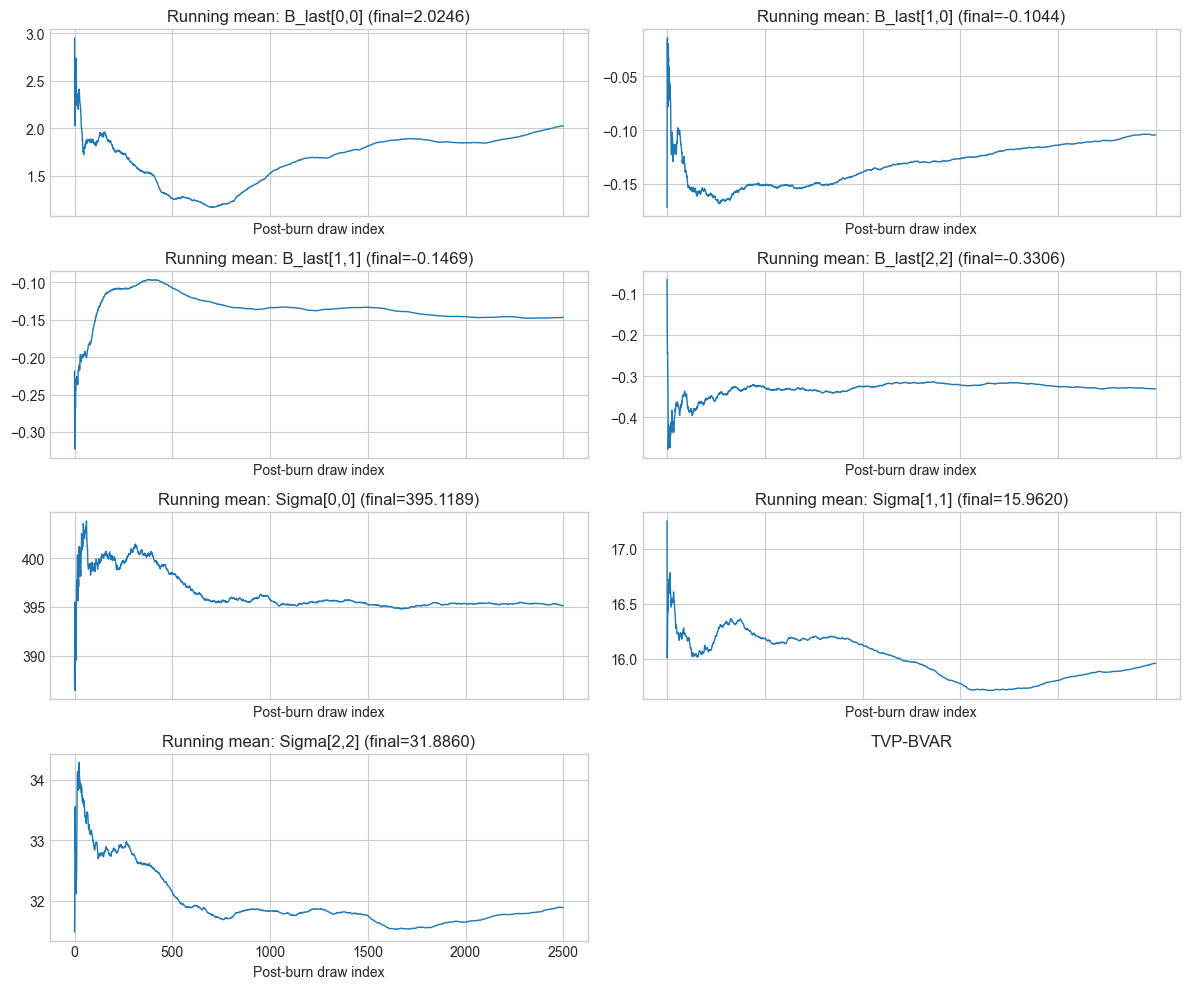

In [5]:
keep_B = bvar['B_draws']
keep_S = bvar['Sigma_draws']

# B_draws has shape (n_keep, T_eff, k, n); use the last-time coefficient matrix.
keep_B_last = keep_B[:, -1, :, :]
idx_B = np.arange(1, keep_B_last.shape[0] + 1)
idx_S = np.arange(1, keep_S.shape[0] + 1)

cum_mean_B00 = np.cumsum(keep_B_last[:, 0, 0]) / idx_B
cum_mean_B10 = np.cumsum(keep_B_last[:, 1, 0]) / idx_B
cum_mean_B11 = np.cumsum(keep_B_last[:, 1, 1]) / idx_B
cum_mean_B22 = np.cumsum(keep_B_last[:, 2, 2]) / idx_B

cum_mean_S00 = np.cumsum(keep_S[:, 0, 0]) / idx_S
cum_mean_S11 = np.cumsum(keep_S[:, 1, 1]) / idx_S
cum_mean_S22 = np.cumsum(keep_S[:, 2, 2]) / idx_S

fig, axes = plt.subplots(4, 2, figsize=(12, 10), sharex=True)
axes = axes.ravel()

series = [
    (cum_mean_B00, 'Running mean: B_last[0,0]'),
    (cum_mean_B10, 'Running mean: B_last[1,0]'),
    (cum_mean_B11, 'Running mean: B_last[1,1]'),
    (cum_mean_B22, 'Running mean: B_last[2,2]'),
    (cum_mean_S00, 'Running mean: Sigma[0,0]'),
    (cum_mean_S11, 'Running mean: Sigma[1,1]'),
    (cum_mean_S22, 'Running mean: Sigma[2,2]'),
]

for i, (s, ttl) in enumerate(series):
    axes[i].plot(s, lw=1)
    axes[i].set_title(f"{ttl} (final={s[-1]:.4f})")
    axes[i].set_xlabel('Post-burn draw index')

axes[-1].axis('off')
plt.title("TVP-BVAR")
plt.tight_layout()
plt.show()

In [6]:
def bvar_state_matrices(B_mat, n=3, p=24):
    """Convert B matrix (k x n) into intercept and companion A."""
    c = B_mat[0, :]  # intercept (n,)
    A_top = B_mat[1:, :].T  # (n, n*p)
    if p == 1:
        A_comp = A_top
    else:
        bottom = np.hstack([np.eye(n * (p - 1)), np.zeros((n * (p - 1), n))])
        A_comp = np.vstack([A_top, bottom])
    return c, A_top, A_comp


def irf_from_companion(A_comp, Sigma, n=3, p=24, h=15):
    """Cholesky-identified IRFs as (n^2, h+1) stacked by columns."""
    J = np.hstack([np.eye(n), np.zeros((n, n * p - n))])
    C = np.linalg.cholesky(Sigma).T
    comp_power = np.eye(n * p)
    irfs = []
    for _ in range(h + 1):
        resp = J @ comp_power @ J.T @ C
        irfs.append(resp.reshape(n * n, 1, order='F'))
        comp_power = comp_power @ A_comp
    return np.hstack(irfs)


def make_var_xy(y, p):
    """Build Y, X with X=[1, y_{t-1},...,y_{t-p}] consistent with notebook ordering."""
    T, n = y.shape
    Y = y[p:, :]
    X_lags = []
    for t in range(p, T):
        row = []
        for L in range(1, p + 1):
            row.extend(y[t - L, :])
        X_lags.append(row)
    X = np.column_stack([np.ones(len(X_lags)), np.asarray(X_lags)])
    return Y, X


def structural_shocks_from_bmean(y, B_mean, Sigma_mean, p=24):
    Y, X = make_var_xy(y, p)
    U = (Y - X @ B_mean).T  # n x (T-p)
    C = np.linalg.cholesky(Sigma_mean).T
    Ehat = np.linalg.solve(C, U)
    return Ehat


def stage2irf(y, q_shock, nrep=20000, seed=1234):
    y = np.asarray(y).reshape(-1, 1)
    q_shock = np.asarray(q_shock).reshape(-1, 1)
    t = len(q_shock)
    pp = 12

    Z = [np.ones((t - pp, 1))]
    for i in range(pp + 1):
        Z.append(q_shock[pp - i:t - i, :])
    Z = np.hstack(Z)

    y_dep = y[pp:t, :]
    bhat = np.linalg.inv(Z.T @ Z) @ Z.T @ y_dep

    irf1hat = bhat[1:, 0]
    cumirf1hat = np.cumsum(irf1hat)

    rng = np.random.default_rng(seed)
    IRF1 = np.zeros((nrep, 13))
    cumIRF1 = np.zeros((nrep, 13))
    block = 4
    y_len = len(y_dep)

    for j in range(nrep):
        yr_blocks, Zr_blocks = [], []
        n_blocks = int(np.ceil(y_len / block))
        for _ in range(n_blocks):
            pos = int(np.ceil(rng.random() * (y_len - block)))
            start = max(0, min(pos - 1, y_len - block))
            yr_blocks.append(y_dep[start:start + block, :])
            Zr_blocks.append(Z[start:start + block, :])

        yr = np.vstack(yr_blocks)[:y_len, :]
        Zr = np.vstack(Zr_blocks)[:y_len, :]

        br = np.linalg.inv(Zr.T @ Zr) @ Zr.T @ yr
        IRF1[j, :] = br[1:, 0]
        cumIRF1[j, :] = np.cumsum(IRF1[j, :])

    q16, q84 = np.quantile(IRF1, [0.16, 0.84], axis=0)
    q025, q975 = np.quantile(IRF1, [0.025, 0.975], axis=0)
    c16, c84 = np.quantile(cumIRF1, [0.16, 0.84], axis=0)
    c025, c975 = np.quantile(cumIRF1, [0.025, 0.975], axis=0)

    return {
        'irf': irf1hat,
        'irf_68': np.vstack([q16, q84]),
        'irf_95': np.vstack([q025, q975]),
        'cum': cumirf1hat,
        'cum_68': np.vstack([c16, c84]),
        'cum_95': np.vstack([c025, c975]),
    }

## Bayesian Figure 2: structural shocks (posterior mean parameters)

In [7]:
p = 24
n = 3
h = 15

y = df.values
Ehat_b = structural_shocks_from_bmean(y, bvar['B_mean_last'], bvar['Sigma_mean'], p=p)

q1 = np.concatenate([[(Ehat_b[0, 0] + Ehat_b[0, 1]) / 2], Ehat_b[0, :]])
q2 = np.concatenate([[(Ehat_b[1, 0] + Ehat_b[1, 1]) / 2], Ehat_b[1, :]])
q3 = np.concatenate([[(Ehat_b[2, 0] + Ehat_b[2, 1]) / 2], Ehat_b[2, :]])

time_year = np.arange(1975, 2007 + 1)
q1a = q1[:len(time_year) * 12].reshape(-1, 12).mean(axis=1)
q2a = q2[:len(time_year) * 12].reshape(-1, 12).mean(axis=1)
q3a = q3[:len(time_year) * 12].reshape(-1, 12).mean(axis=1)

fig, axes = plt.subplots(3, 1, figsize=(10, 9), sharex=True)
for ax, s, ttl in zip(
    axes,
    [q1a, q2a, q3a],
    ['Oil Supply Shock (BVAR)', 'Aggregate Demand Shock (BVAR)', 'Oil-Specific Demand Shock (BVAR)']
):
    ax.plot(time_year, s)
    ax.axhline(0, color='k', lw=0.8)
    ax.set_xlim(1975, 2007)
    ax.set_ylim(-1, 1)
    ax.set_title(ttl)

plt.tight_layout()
plt.title("TVP-BVAR")
plt.show()

ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 19 is different from 73)

## Bayesian Figure 3: IRFs and credible intervals from posterior draws

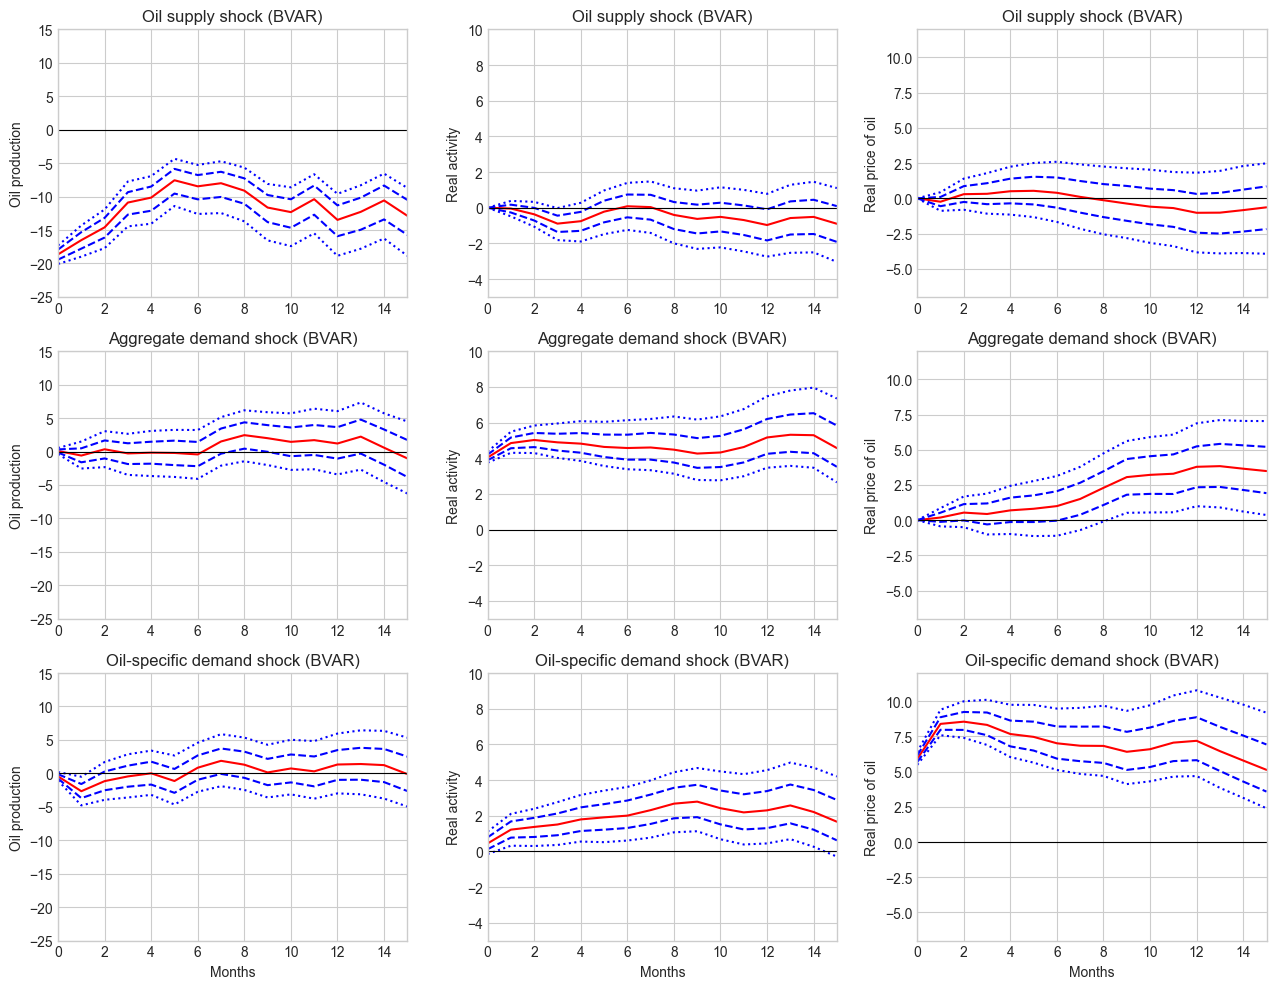

In [ ]:
# Posterior draw IRFs for credible bands
n_keep = bvar['B_draws'].shape[0]
max_draws = min(2000, n_keep)
idx = np.linspace(0, n_keep - 1, max_draws, dtype=int)

IRF_draws = np.zeros((max_draws, n * n, h + 1))
for j, d in enumerate(idx):
    B_d = bvar['B_draws'][d]
    S_d = bvar['Sigma_draws'][d]
    _, _, A_comp_d = bvar_state_matrices(B_d, n=n, p=p)
    irf_d = irf_from_companion(A_comp_d, S_d, n=n, p=p, h=h)
    irf_d[0, :] = np.cumsum(irf_d[0, :])
    irf_d[3, :] = np.cumsum(irf_d[3, :])
    irf_d[6, :] = np.cumsum(irf_d[6, :])
    IRF_draws[j] = irf_d

IRF_med = np.median(IRF_draws, axis=0)
IRF_68 = np.quantile(IRF_draws, [0.16, 0.84], axis=0)
IRF_95 = np.quantile(IRF_draws, [0.025, 0.975], axis=0)

horizon = np.arange(0, h + 1)
fig, axes = plt.subplots(3, 3, figsize=(13, 10))
axes = axes.ravel()

meta = [
    ('Oil supply shock (BVAR)', 'Oil production', (-25, 15), -1),
    ('Oil supply shock (BVAR)', 'Real activity', (-5, 10), -1),
    ('Oil supply shock (BVAR)', 'Real price of oil', (-7, 12), -1),
    ('Aggregate demand shock (BVAR)', 'Oil production', (-25, 15), 1),
    ('Aggregate demand shock (BVAR)', 'Real activity', (-5, 10), 1),
    ('Aggregate demand shock (BVAR)', 'Real price of oil', (-7, 12), 1),
    ('Oil-specific demand shock (BVAR)', 'Oil production', (-25, 15), 1),
    ('Oil-specific demand shock (BVAR)', 'Real activity', (-5, 10), 1),
    ('Oil-specific demand shock (BVAR)', 'Real price of oil', (-7, 12), 1),
]

for i, (ttl, yl, ylim, sgn) in enumerate(meta):
    ax = axes[i]
    m = sgn * IRF_med[i]
    l68, u68 = sgn * IRF_68[0, i], sgn * IRF_68[1, i]
    l95, u95 = sgn * IRF_95[0, i], sgn * IRF_95[1, i]
    lo68, hi68 = np.minimum(l68, u68), np.maximum(l68, u68)
    lo95, hi95 = np.minimum(l95, u95), np.maximum(l95, u95)

    ax.plot(horizon, m, 'r-')
    ax.plot(horizon, lo68, 'b--')
    ax.plot(horizon, hi68, 'b--')
    ax.plot(horizon, lo95, 'b:')
    ax.plot(horizon, hi95, 'b:')
    ax.axhline(0, color='k', lw=0.8)
    ax.set_title(ttl)
    ax.set_ylabel(yl)
    ax.set_xlim(0, h)
    ax.set_ylim(*ylim)
    if i >= 6:
        ax.set_xlabel('Months')

plt.tight_layout()
plt.title("TVP-BVAR")
plt.show()

## Bayesian Figure 4: cumulative effect on real oil price

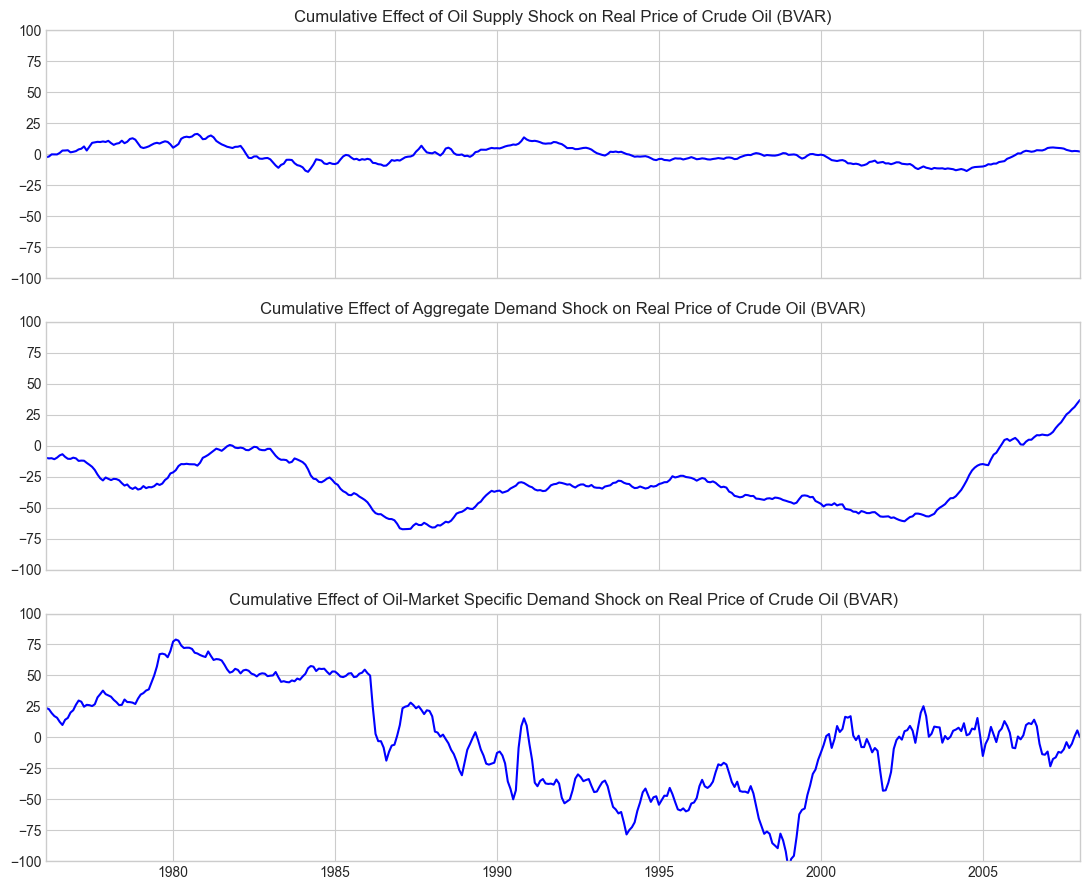

In [ ]:
T = y.shape[0]
_, _, A_comp_mean = bvar_state_matrices(bvar['B_mean'], n=n, p=p)
IRF_long = irf_from_companion(A_comp_mean, bvar['Sigma_mean'], n=n, p=p, h=T - p - 1)

yhat1 = np.zeros(T - p)
yhat2 = np.zeros(T - p)
yhat3 = np.zeros(T - p)
for i in range(T - p):
    idx_i = np.arange(i + 1)
    yhat1[i] = np.dot(IRF_long[2, idx_i], Ehat_b[0, i::-1])
    yhat2[i] = np.dot(IRF_long[5, idx_i], Ehat_b[1, i::-1])
    yhat3[i] = np.dot(IRF_long[8, idx_i], Ehat_b[2, i::-1])

time = np.arange(1975 + 2 / 12, 2007 + 12 / 12 + 1e-9, 1 / 12)
fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=True)

axes[0].plot(time, yhat1, 'b-')
axes[0].set_title('Cumulative Effect of Oil Supply Shock on Real Price of Crude Oil (BVAR)')
axes[0].set_xlim(1976 + 1 / 12, 2007 + 12 / 12)
axes[0].set_ylim(-100, 100)

axes[1].plot(time, yhat2, 'b-')
axes[1].set_title('Cumulative Effect of Aggregate Demand Shock on Real Price of Crude Oil (BVAR)')
axes[1].set_xlim(1976 + 1 / 12, 2007 + 12 / 12)
axes[1].set_ylim(-100, 100)

axes[2].plot(time, yhat3, 'b-')
axes[2].set_title('Cumulative Effect of Oil-Market Specific Demand Shock on Real Price of Crude Oil (BVAR)')
axes[2].set_xlim(1976 + 1 / 12, 2007 + 12 / 12)
axes[2].set_ylim(-100, 100)

plt.tight_layout()
plt.title("TVP-BVAR")
plt.show()

## Bayesian Figure 5-style responses: shocks on real GDP and CPI

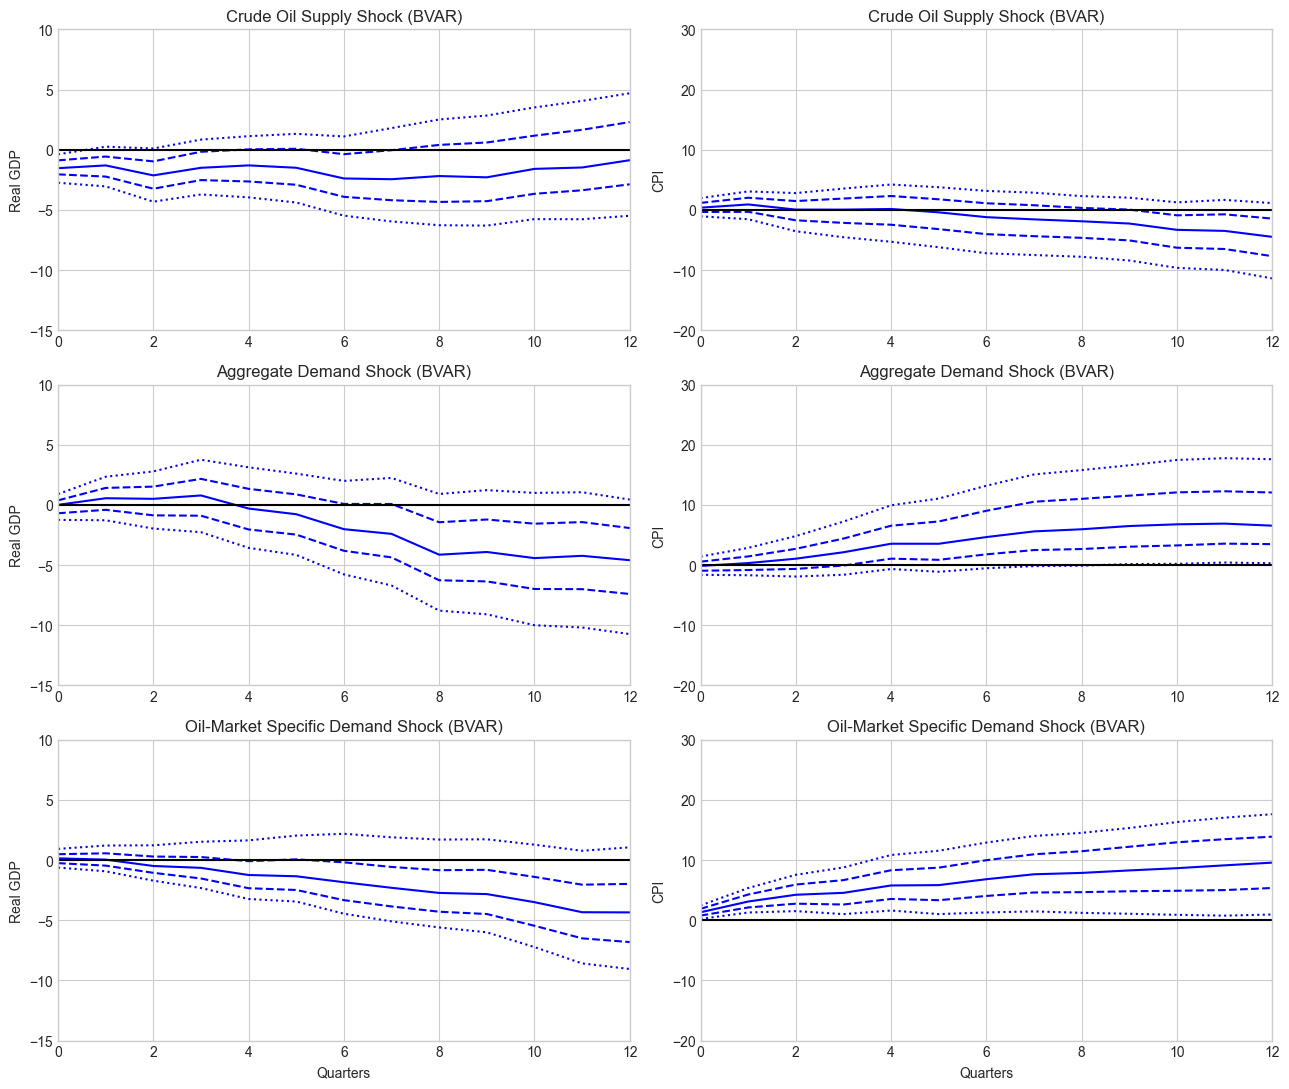

In [ ]:
# Quarterly average structural shocks from BVAR
q1 = np.concatenate([[(Ehat_b[0, 0] + Ehat_b[0, 1]) / 2], Ehat_b[0, :]])
q2 = np.concatenate([[(Ehat_b[1, 0] + Ehat_b[1, 1]) / 2], Ehat_b[1, :]])
q3 = np.concatenate([[(Ehat_b[2, 0] + Ehat_b[2, 1]) / 2], Ehat_b[2, :]])

quarter_time = np.arange(1975 + 1 / 4, 2007 + 4 / 4 + 1e-9, 1 / 4)
nq = len(quarter_time)
q1q = q1[:3 * nq].reshape(-1, 3).mean(axis=1)
q2q = q2[:3 * nq].reshape(-1, 3).mean(axis=1)
q3q = q3[:3 * nq].reshape(-1, 3).mean(axis=1)

# GDP series
beagdp = np.loadtxt(BASE_DIR / 'beagdp.txt')
gdp = beagdp[:, 2]
y_gdp = (np.log(gdp[1:]) - np.log(gdp[:-1]))[:, None] * 400

# CPI inflation series
cpi_raw = np.loadtxt(BASE_DIR / 'cpi.txt')
cpi = np.log(cpi_raw[:, 2])
infl = np.array([(cpi[3 * i] - cpi[3 * (i - 1)]) * 400 for i in range(1, len(quarter_time) + 1)])
y_cpi = infl[:, None]

# Stage-2 responses
nrep_stage2 = 20000
r2 = stage2irf(y_gdp, q1q, nrep=nrep_stage2, seed=1234)
r3 = stage2irf(y_gdp, q2q, nrep=nrep_stage2, seed=1234)
r4 = stage2irf(y_gdp, q3q, nrep=nrep_stage2, seed=1234)

c2 = stage2irf(y_cpi, q1q, nrep=nrep_stage2, seed=1234)
c3 = stage2irf(y_cpi, q2q, nrep=nrep_stage2, seed=1234)
c4 = stage2irf(y_cpi, q3q, nrep=nrep_stage2, seed=1234)

h2 = np.arange(13)
fig, axes = plt.subplots(3, 2, figsize=(13, 11))

# GDP panels
for ax, rr, ttl, sgn in [
    (axes[0, 0], r2, 'Crude Oil Supply Shock (BVAR)', -1),
    (axes[1, 0], r3, 'Aggregate Demand Shock (BVAR)', 1),
    (axes[2, 0], r4, 'Oil-Market Specific Demand Shock (BVAR)', 1),
]:
    m = sgn * rr['cum']
    lo68 = sgn * rr['cum_68'][0]
    hi68 = sgn * rr['cum_68'][1]
    lo95 = sgn * rr['cum_95'][0]
    hi95 = sgn * rr['cum_95'][1]
    a68, b68 = np.minimum(lo68, hi68), np.maximum(lo68, hi68)
    a95, b95 = np.minimum(lo95, hi95), np.maximum(lo95, hi95)

    ax.plot(h2, m, 'b-')
    ax.plot(h2, a68, 'b--')
    ax.plot(h2, b68, 'b--')
    ax.plot(h2, a95, 'b:')
    ax.plot(h2, b95, 'b:')
    ax.plot(h2, np.zeros_like(h2), 'k-')
    ax.set_xlim(0, 12)
    ax.set_ylim(-15, 10)
    ax.set_ylabel('Real GDP')
    ax.set_title(ttl)
axes[2, 0].set_xlabel('Quarters')

# CPI panels
for ax, rr, ttl, sgn in [
    (axes[0, 1], c2, 'Crude Oil Supply Shock (BVAR)', -1),
    (axes[1, 1], c3, 'Aggregate Demand Shock (BVAR)', 1),
    (axes[2, 1], c4, 'Oil-Market Specific Demand Shock (BVAR)', 1),
]:
    m = sgn * rr['cum']
    lo68 = sgn * rr['cum_68'][0]
    hi68 = sgn * rr['cum_68'][1]
    lo95 = sgn * rr['cum_95'][0]
    hi95 = sgn * rr['cum_95'][1]
    a68, b68 = np.minimum(lo68, hi68), np.maximum(lo68, hi68)
    a95, b95 = np.minimum(lo95, hi95), np.maximum(lo95, hi95)

    ax.plot(h2, m, 'b-')
    ax.plot(h2, a68, 'b--')
    ax.plot(h2, b68, 'b--')
    ax.plot(h2, a95, 'b:')
    ax.plot(h2, b95, 'b:')
    ax.plot(h2, np.zeros_like(h2), 'k-')
    ax.set_xlim(0, 12)
    ax.set_ylim(-20, 30)
    ax.set_ylabel('CPI')
    ax.set_title(ttl)
axes[2, 1].set_xlabel('Quarters')

plt.tight_layout()
plt.title("TVP-BVAR")
plt.show()